In [1]:
# https://www.kaggle.com/competitions/neoai-2026-day-2-cv

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
import albumentations as A
import cv2

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

np.random.seed(42)

In [2]:
def load_images(csv_file, images_folder):
    df = pd.read_csv(csv_file)
    features, labels, filenames = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = Image.open(os.path.join(images_folder, row['id']))
        features.append(np.array(img))
        filenames.append(row['id'])
        if 'label' in row:
            labels.append(row['label'])
    features = np.array(features)
    if labels:
        return features, np.array(labels), filenames
    return features, filenames   

In [3]:
X_train, y_train, _ = load_images('/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/train.csv', '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/train')
X_test, _ = load_images('/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/test.csv', '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/test')
print(f'train: {X_train.shape}  test: {X_test.shape}  classes: {len(np.unique(y_train))}')

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

train: (50, 32, 32, 3)  test: (5000, 32, 32, 3)  classes: 5


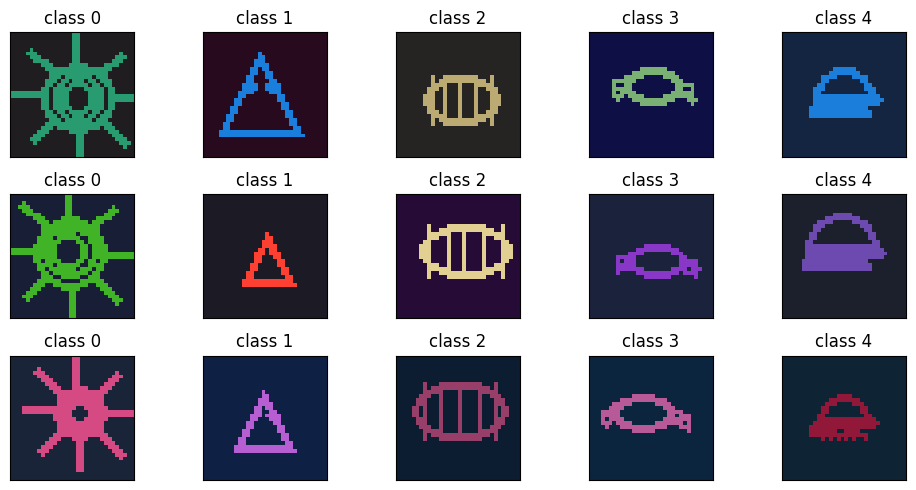

In [4]:
plt.figure(figsize=(10,5))

for look in range(3):
    for i in range(5):
        plt.subplot(3, 5, look*5+i+1)
        plt.imshow(X_train[np.where(y_train==i)[0][look]])
        plt.xticks([])
        plt.yticks([])
        plt.title(f'class {i}')
        
plt.tight_layout()
plt.show()

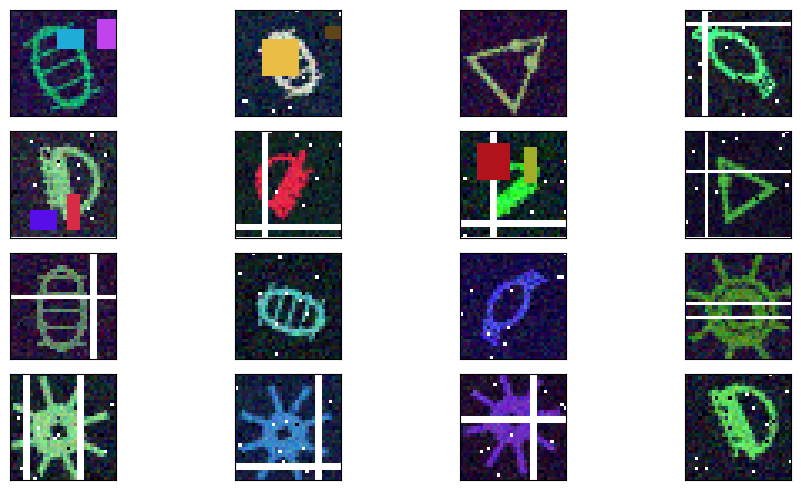

In [5]:
plt.figure(figsize=(10,5))

nrows, ncols = 4, 4
indices = np.random.choice(range(len(X_test)), size=nrows*ncols, replace=False)

for row in range(nrows):
    for col in range(ncols):
        idx = row*ncols+col
        plt.subplot(nrows, ncols, idx+1)
        plt.imshow(X_test[indices[idx]])
        plt.xticks([])
        plt.yticks([])
        
plt.tight_layout()
plt.show()

In [6]:
class RandomRectangleAddition(A.ImageOnlyTransform):
    def __init__(self, max_rectangles=2, min_size=3, max_size=12, p=0.5):
        super().__init__(p=p)
        self.max_rectangles = max_rectangles
        self.min_size = min_size
        self.max_size = max_size

    def apply(self, image, **params):
        image = image.copy()
        h, w, _ = image.shape
        num_rectangles = random.randint(1, self.max_rectangles)
        
        for _ in range(num_rectangles):
            rect_width = random.randint(self.min_size, self.max_size)
            rect_height = random.randint(self.min_size, self.max_size)
            top_left_x = random.randint(0, w - rect_width)
            top_left_y = random.randint(0, h - rect_height)

            # Choose a random color
            color = tuple(random.randint(0, 255) for _ in range(3))
            cv2.rectangle(image, (top_left_x, top_left_y), (top_left_x + rect_width, top_left_y + rect_height), color, -1)

        return image

class RandomWhiteStripes(A.ImageOnlyTransform):
    def __init__(self, max_width=10, max_stripes=2, length=1.0, p=0.5):
        super().__init__(p=p)
        self.max_width = max_width  # Maximum width of the stripe
        self.max_stripes = max_stripes
        self.length = length  # Length of the stripe as a fraction of the image dimension

    def apply(self, image, **params):
        image = image.copy()
        h, w, _ = image.shape

        for _ in range(random.randrange(1, self.max_stripes+1)):
            # Decide whether to draw a vertical or horizontal stripe
            if random.choice([True, False]):  # Randomly choose between vertical and horizontal
                # Vertical stripe
                stripe_width = random.randint(1, self.max_width)
                x_position = random.randint(0, w - stripe_width)
                stripe_length = int(h * self.length)  # Calculate length based on the image height
                image[x_position:x_position + stripe_width, :stripe_length] = 255  # White stripe
            else:
                # Horizontal stripe
                stripe_width = random.randint(1, self.max_width)
                y_position = random.randint(0, h - stripe_width)
                stripe_length = int(w * self.length)  # Calculate length based on the image width
                image[:stripe_length, y_position:y_position + stripe_width] = 255  # White stripe

        return image

    def get_transform_init_args_names(self):
        return ('max_width', 'length')

transform = A.Compose([
    A.Rotate(limit=(-180, 180), p=0.85),
    A.VerticalFlip(0.85),
    A.HorizontalFlip(0.85),
    A.RandomScale(scale_limit=(0.0, 0.5), p=0.85),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.85),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.85),
    A.SaltAndPepper(p=0.85),
    A.ChannelShuffle(p=0.85),
    A.RandomCrop(32, 32),
    RandomWhiteStripes(max_width=5, length=1.0, p=0.85),
    RandomRectangleAddition(p=0.85),
])

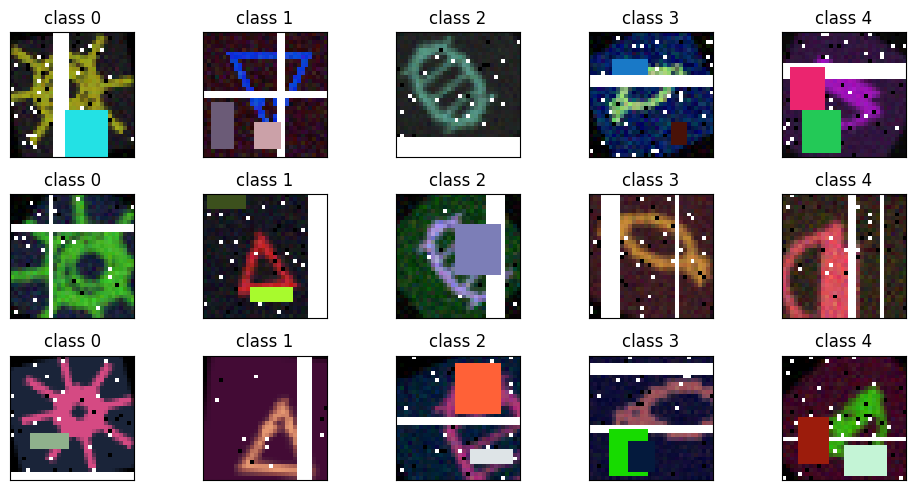

In [7]:
plt.figure(figsize=(10,5))

for look in range(3):
    for i in range(5):
        plt.subplot(3, 5, look*5+i+1)
        plt.imshow(transform(image=X_train[np.where(y_train==i)[0][look]])['image'])
        plt.xticks([])
        plt.yticks([])
        plt.title(f'class {i}')
        
plt.tight_layout()
plt.show()

In [8]:
class ImageDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        """Returns the number of images in the dataset."""
        return len(self.images)

    def __getitem__(self, index: int) -> np.ndarray:
        """
        Retrieves an image by index and applies the transform if provided.

        :param index: Index of the image to retrieve.
        :return: Transformed image as a NumPy array.
        """
        image = self.images[index]
        
        if self.transform:
            image = self.transform(image=image)['image']

        image = image / 255
        
        if self.labels is None:
            return image

        label = self.labels[index]
        return image, label

transform = A.Compose([
    A.Rotate(limit=(-180, 180), p=0.85),
    A.VerticalFlip(0.85),
    A.HorizontalFlip(0.85),
    A.RandomScale(scale_limit=(0.0, 0.5), p=0.85),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.85),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.85),
    A.SaltAndPepper(p=0.85),
    A.ChannelShuffle(p=0.85),
    A.RandomCrop(32, 32),
    RandomWhiteStripes(max_width=3, length=1.0, p=0.85),
    RandomRectangleAddition(p=0.85),
    A.ToTensorV2()
])

test_transform = A.ToTensorV2()

tr_rep = 160
va_rep = 32

train_ds = ImageDataset(np.repeat(X_train, tr_rep, 0), np.repeat(y_train, tr_rep, 0), transform)
valid_ds = ImageDataset(np.repeat(X_train, va_rep, 0), np.repeat(y_train, va_rep, 0), transform)
test_ds = ImageDataset(X_test, transform=test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(valid_loader), len(test_loader)

(250, 50, 157)

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Define the layers of the CNN
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)  # Output: (32, 32, 32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)  # Output: (64, 32, 32)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3, stride=1, padding=1)  # Output: (128, 32, 32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)  # Reduces size by half
        self.fc1 = nn.Linear(256 * 4 * 4, 256)  # Fully connected layer
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(256, 5)  # Output layer for 5 classes
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(256)

    def forward(self, x):
        # Forward pass through the network
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # (32, 16, 16)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # (64, 8, 8)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # (128, 4, 4)
        x = x.view(-1, 256 * 4 * 4)  # Flatten the tensor
        x = F.relu(self.dropout(self.fc1(x)))  # First fully connected layer
        x = self.fc2(x)  # Output layer
        return x

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [11]:
# Assuming you have defined your CNN model
# model = YourCNNModel().to(device)

num_epochs = 100  # Set the number of epochs
log_interval = 10  # How often to log metrics

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

for epoch in tqdm(range(num_epochs), desc='Epoch'):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc='Train Loader', leave=False)):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()  # Zero the gradients
        output = model(data)  # Forward pass
        
        loss = criterion(output, target)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        running_loss += loss.item()
        preds = torch.argmax(output, dim=1)  # Get predictions
        all_labels.extend(target.cpu().numpy())  # Collect true labels
        all_preds.extend(preds.cpu().numpy())  # Collect predictions

    # Calculate average loss and F1 score for the epoch
    avg_loss = running_loss / len(train_loader)
    f1_micro = f1_score(all_labels, all_preds, average='micro')

    if (epoch+1) % log_interval == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.4f}, F1 Micro: {f1_micro:.4f}')
    
    # scheduler.step()

    if (epoch+1) % log_interval != 0:
        continue
    
    model.eval()  # Set the model to training mode
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for batch_idx, (data, target) in enumerate(tqdm(valid_loader, desc='Valid Loader', leave=False)):
        data, target = data.to(device), target.to(device)

        with torch.no_grad():
            output = model(data)  # Forward pass
            loss = criterion(output, target)  # Compute loss
        
        running_loss += loss.item()
        preds = torch.argmax(output, dim=1)  # Get predictions
        all_labels.extend(target.cpu().numpy())  # Collect true labels
        all_preds.extend(preds.cpu().numpy())  # Collect predictions

    # Calculate average loss and F1 score for the epoch
    avg_loss = running_loss / len(train_loader)
    f1_micro = f1_score(all_labels, all_preds, average='micro')

    print(f'Valid Loss: {avg_loss:.4f}, F1 Micro: {f1_micro:.4f}')

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/250 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/250 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/250 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/250 [00:00<?, ?it/s]

...

Train Loader:   0%|          | 0/250 [00:00<?, ?it/s]

Train Loader:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch [100/100], Train Loss: 0.0539, F1 Micro: 0.9808


Valid Loader:   0%|          | 0/50 [00:00<?, ?it/s]

Valid Loss: 0.0056, F1 Micro: 0.9906


In [12]:
model.eval()  # Set the model to training mode
all_preds = []

for batch_idx, (data) in enumerate(tqdm(test_loader, desc='Test Loader', leave=True)):
    data = data.to(device)

    with torch.no_grad():
        output = model(data)  # Forward pass
        
    preds = torch.argmax(output, dim=1)  # Get predictions
    all_preds.extend(preds.cpu().numpy())  # Collect predictions

Test Loader:   0%|          | 0/157 [00:00<?, ?it/s]

In [13]:
subm = pd.read_csv("/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/sample_submission.csv")

subm['label'] = all_preds

subm.to_csv("submission.csv", index=False)

subm.head()

,id,label
0,00000.png,2
1,00001.png,2
2,00002.png,4
3,00003.png,3
4,00004.png,4


In [14]:
subm['label'].value_counts()

label
4    1051
0    1000
2     989
1     988
3     972
Name: count, dtype: int64